# Machine Learning for Physicists — Part 2
## Neural Networks and Classification

**PHY432 — Computational Methods in Physics**  
Arizona State University


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 12


---
## 1. Classification: Predicting Categories

**Regression** → predict a *number* (force, energy, position)  
**Classification** → predict a *category* (muon or electron? ordered or disordered phase?)

### Our dataset: particle detector

Two features per event:
- $x_1$ = normalised transverse momentum $p_T$
- $x_2$ = normalised energy-momentum ratio $E/p$

Two classes: **signal** (particle we want) and **background** (noise).  
The catch: signal forms a **ring** around background. No straight line can separate them.


Training: 400 events   |   Test: 100 events
Class balance — Background: 250, Signal: 250


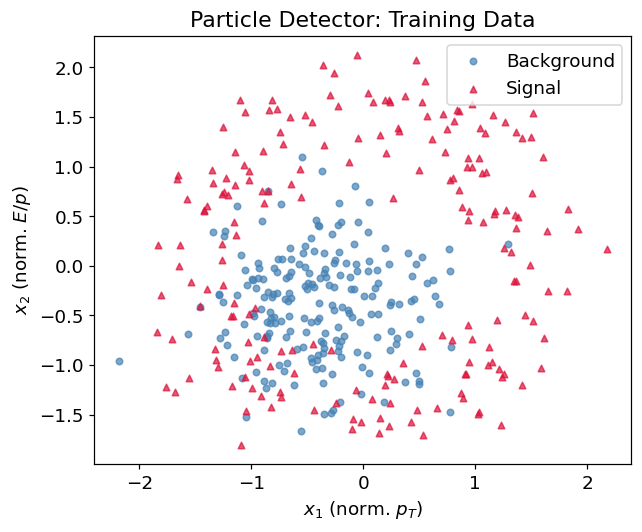

Signal (red) forms a ring — no straight line can separate these classes!


In [2]:
def make_particle_data(N=500):
    """
    Simulate 2-class particle detector data.
    Class 0 = background: clustered near the origin.
    Class 1 = signal: forms a ring at radius ~1.5 around origin.
    """
    n_each = N // 2

    # Background: Gaussian blob
    X0 = np.random.randn(n_each, 2) * 0.55 + np.array([-0.4, -0.4])

    # Signal: ring shape
    angles = np.random.uniform(0, 2*np.pi, n_each)
    radii  = np.random.uniform(1.1, 1.9, n_each)
    X1 = np.column_stack([radii * np.cos(angles),
                          radii * np.sin(angles)])
    X1 += np.random.randn(n_each, 2) * 0.2

    X = np.vstack([X0, X1])
    y = np.array([0]*n_each + [1]*n_each)
    idx = np.random.permutation(N)
    return X[idx], y[idx]

X, y = make_particle_data(N=500)

# 80% train, 20% test
split = int(0.8 * len(y))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training: {split} events   |   Test: {len(y)-split} events")
print(f"Class balance — Background: {(y==0).sum()}, Signal: {(y==1).sum()}")

fig, ax = plt.subplots(figsize=(6, 5))
for label, name, color, marker in [(0,'Background','steelblue','o'), (1,'Signal','crimson','^')]:
    m = y_train == label
    ax.scatter(X_train[m,0], X_train[m,1], c=color, marker=marker, s=18, alpha=0.7, label=name)
ax.set_xlabel(r'$x_1$ (norm. $p_T$)')
ax.set_ylabel(r'$x_2$ (norm. $E/p$)')
ax.set_title('Particle Detector: Training Data')
ax.legend()
plt.tight_layout()
plt.show()

print("Signal (red) forms a ring — no straight line can separate these classes!")

---
## 2. How Do We Know If a Classifier Is Good?

### The Confusion Matrix

| | Predicted: Background | Predicted: Signal |
|---|---|---|
| **Actual: Background** | ✅ True Negative (TN) | ❌ False Positive (FP) |
| **Actual: Signal** | ❌ False Negative (FN) | ✅ True Positive (TP) |

### Three numbers that matter

| Metric | Formula | Physics meaning |
|---|---|---|
| **Accuracy** | $(TP+TN)\,/\,N$ | Fraction of all events correct |
| **Precision** | $TP\,/\,(TP+FP)$ | Purity — how clean is our selected sample? |
| **Recall** | $TP\,/\,(TP+FN)$ | Efficiency — what fraction of signal did we keep? |

> **Tradeoff:** stricter cut → higher purity, lower efficiency. You choose based on the physics goal.


In [3]:
def compute_metrics(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return {
        "Accuracy":  (TP + TN) / (TP + TN + FP + FN),
        "Precision": TP / (TP + FP + 1e-9),
        "Recall":    TP / (TP + FN + 1e-9),
        "TP": TP, "TN": TN, "FP": FP, "FN": FN,
    }

def print_metrics(m, label=""):
    print(f"\n--- {label} ---")
    print(f"  Accuracy={m['Accuracy']:.3f}  Precision={m['Precision']:.3f}  Recall={m['Recall']:.3f}")
    print(f"  TP={m['TP']}  TN={m['TN']}  FP={m['FP']}  FN={m['FN']}")


---
## 3. A First Classifier: Logistic Regression

Compute a weighted sum of the inputs, then squash it to a probability with the **sigmoid**:

$$\hat{p} = \sigma(\theta_0 + \theta_1 x_1 + \theta_2 x_2), \qquad \sigma(z) = \frac{1}{1+e^{-z}}$$

Predict *signal* if $\hat{p} \geq 0.5$.

The decision boundary is always a **straight line** — we already know this will fail on the ring data.  
We include it as a baseline to make the neural network result meaningful.


In [4]:
def sigmoid(z):
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

class LogisticRegression:
    def __init__(self, lr=0.3, n_iter=2000):
        self.lr, self.n_iter, self.theta = lr, n_iter, None

    def fit(self, X, y):
        Xb = np.column_stack([np.ones(len(X)), X])
        self.theta = np.zeros(Xb.shape[1])
        for _ in range(self.n_iter):
            grad = Xb.T @ (sigmoid(Xb @ self.theta) - y) / len(y)
            self.theta -= self.lr * grad
        return self

    def predict_proba(self, X):
        return sigmoid(np.column_stack([np.ones(len(X)), X]) @ self.theta)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_metrics = compute_metrics(y_test, lr_model.predict(X_test))
print_metrics(lr_metrics, "Logistic Regression")



--- Logistic Regression ---
  Accuracy=0.640  Precision=0.714  Recall=0.556
  TP=30  TN=34  FP=12  FN=24


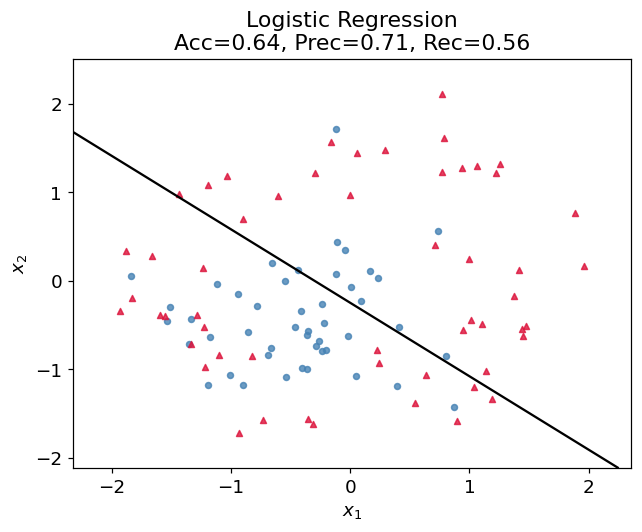

The black line is the decision boundary — it's a straight line.
It cannot wrap around the ring-shaped signal, so many events are misclassified.


In [9]:
def plot_boundary(model_fn, X, y, title, ax):
    """Shade decision regions and plot data points."""
    x1min, x1max = X[:,0].min()-0.4, X[:,0].max()+0.4
    x2min, x2max = X[:,1].min()-0.4, X[:,1].max()+0.4
    xx1, xx2 = np.meshgrid(np.arange(x1min, x1max, 0.06),
                            np.arange(x2min, x2max, 0.06))
    Z = model_fn(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    #ax.contourf(xx1, xx2, Z, alpha=0.35, cmap=ListedColormap(['#AED6F1','#F1948A']))
    ax.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=1.5)
    for lab, col, mk in [(0,'steelblue','o'), (1,'crimson','^')]:
        m = y == lab
        ax.scatter(X[m,0], X[m,1], c=col, marker=mk, s=15, alpha=0.8)
    ax.set_xlim(x1min, x1max); ax.set_ylim(x2min, x2max)
    ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(6, 5))
plot_boundary(lr_model.predict_proba, X_test, y_test,
              f"Logistic Regression\nAcc={lr_metrics['Accuracy']:.2f}, "
              f"Prec={lr_metrics['Precision']:.2f}, Rec={lr_metrics['Recall']:.2f}", ax)
plt.tight_layout()
plt.show()

def bce_loss(y, p_hat):
    p = np.clip(p_hat, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

print("The black line is the decision boundary — it's a straight line.")
print("It cannot wrap around the ring-shaped signal, so many events are misclassified.")

---
## 4. Neural Networks: Curved Decision Boundaries

Unlike logistic regression, a neural network can draw **curved** decision boundaries — enough to wrap around a ring. A neural network gets around the "straight line only" problem of logistic regression by combining many simple functions (for example 16 in our case) to carve out a curved boundary — enough to wrap around a ring. Training just means repeatedly nudging all the parameters until the boundary fits the data, and backpropagation is the bookkeeping that tells you which direction to nudge each one. 

Our network passes data through two stages:

Input (x1, x2)  →  Hidden layer (16 neurons)  →  Output (probability)

Each of the 16 neurons computes a weighted sum of the inputs — just like logistic regression — but then clips negative values to zero. Think of it like a detector threshold: below zero, no signal; above zero, the value passes through. This is Rectified Linear Unit (ReLU). With 16 neurons each "triggering" in different regions of the input space, the network can piece together a curved boundary from many small flat pieces.

The output layer combines all 16 into one final number, then passes it through the sigmoid — which maps any number to a probability between 0 and 1. Same sigmoid as logistic regression, just now at the end of a longer pipeline. The sigmoid converts a raw number (could be anything — negative, huge, whatever) into a probability between 0 and 1, so you can make a decision: e.g. above 0.5 → signal, below 0.5 → background.

In [10]:
class NeuralNetwork:
    """
    A simple 2-layer neural network, built entirely in NumPy.

    Architecture:
      Input (d features)
        → Hidden layer (n_hidden neurons, ReLU activation)
        → Output (1 neuron, sigmoid activation → probability)

    Loss: Binary Cross-Entropy (same as logistic regression)
    Training: gradient descent with backpropagation
    """

    def __init__(self, n_input, n_hidden, lr=0.05, n_iter=2500):
        self.lr, self.n_iter = lr, n_iter
        # Initialise weights with small random values
        # sqrt(2/n) scaling keeps the signal from shrinking or exploding
        self.W1 = np.random.randn(n_hidden, n_input) * np.sqrt(2/n_input)
        self.b1 = np.zeros(n_hidden)
        self.W2 = np.random.randn(1, n_hidden) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros(1)
        self.loss_history = []

    def forward(self, X):
        """Run one forward pass: X → hidden layer → output probability."""
        z1    = X @ self.W1.T + self.b1        # weighted sum at hidden layer
        h1    = np.maximum(0, z1)              # ReLU activation
        z2    = h1 @ self.W2.T + self.b2      # weighted sum at output
        p_hat = sigmoid(z2).ravel()            # sigmoid → probability
        return p_hat, (X, z1, h1)

    def backward(self, y, p_hat, cache):
        """Compute gradients using backpropagation (chain rule)."""
        X, z1, h1 = cache
        N = len(y)

        # Output layer: gradient of BCE + sigmoid is simply (p_hat - y)
        dz2 = (p_hat - y) / N             # how wrong the output is
        dW2 = dz2[:, None].T @ h1         # gradient for output weights
        db2 = np.sum(dz2, keepdims=True)  # gradient for output bias

        # Hidden layer: chain rule back through W2, then through ReLU
        dh1 = dz2[:, None] @ self.W2      # gradient reaching hidden layer outputs
        dz1 = dh1 * (z1 > 0)             # chain rule through ReLU (derivative = 1 if z>0, else 0)
        dW1 = dz1.T @ X                   # gradient for hidden weights
        db1 = dz1.sum(axis=0)             # gradient for hidden bias

        return dW1, db1, dW2, db2

    def fit(self, X, y, verbose=True):
        for epoch in range(self.n_iter):
            p_hat, cache = self.forward(X)
            loss = bce_loss(y, p_hat)
            self.loss_history.append(loss)
            dW1, db1, dW2, db2 = self.backward(y, p_hat, cache)
            # Gradient descent update for all four parameter arrays
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            if verbose and epoch % 500 == 0:
                acc = np.mean((p_hat >= 0.5).astype(int) == y)
                print(f"  Epoch {epoch:4d}  loss={loss:.4f}  train acc={acc:.3f}")
        return self

    def predict_proba(self, X):
        p_hat, _ = self.forward(X)
        return p_hat

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


print("Training neural network (16 hidden neurons)...")
nn = NeuralNetwork(n_input=2, n_hidden=16, lr=0.05, n_iter=2500)
nn.fit(X_train, y_train)

nn_preds   = nn.predict(X_test)
nn_metrics = compute_metrics(y_test, nn_preds)
print_metrics(nn_metrics, "Neural Network on Test Set")

Training neural network (16 hidden neurons)...
  Epoch    0  loss=1.3528  train acc=0.510
  Epoch  500  loss=0.3843  train acc=0.828
  Epoch 1000  loss=0.3123  train acc=0.853
  Epoch 1500  loss=0.2912  train acc=0.855
  Epoch 2000  loss=0.2840  train acc=0.850

--- Neural Network on Test Set ---
  Accuracy=0.800  Precision=0.793  Recall=0.852
  TP=46  TN=34  FP=12  FN=8


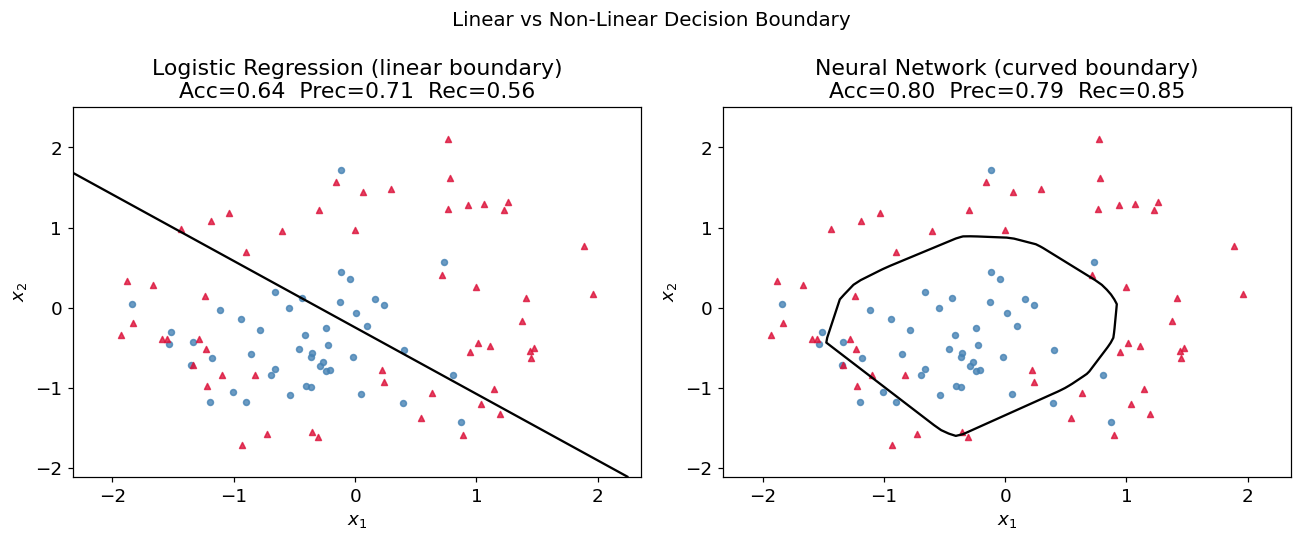

Left: Logistic regression can only draw a straight line — many events are wrong.
Right: Neural network draws a curved loop around the ring-shaped signal — much better!


In [11]:
# Compare decision boundaries side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_boundary(lr_model.predict_proba, X_test, y_test,
              f"Logistic Regression (linear boundary)\n"
              f"Acc={lr_metrics['Accuracy']:.2f}  Prec={lr_metrics['Precision']:.2f}  Rec={lr_metrics['Recall']:.2f}",
              axes[0])

plot_boundary(nn.predict_proba, X_test, y_test,
              f"Neural Network (curved boundary)\n"
              f"Acc={nn_metrics['Accuracy']:.2f}  Prec={nn_metrics['Precision']:.2f}  Rec={nn_metrics['Recall']:.2f}",
              axes[1])

plt.suptitle('Linear vs Non-Linear Decision Boundary', fontsize=13)
plt.tight_layout()
plt.show()

print("Left: Logistic regression can only draw a straight line — many events are wrong.")
print("Right: Neural network draws a curved loop around the ring-shaped signal — much better!")

---
## Summary

| | Logistic Regression | Neural Network |
|---|---|---|
| Decision boundary | Straight line | Curved, arbitrary |
| Works on ring data? | ❌ | ✅ |
| Training | Gradient descent | Gradient descent + backprop |

**The key point:** more expressive models can learn more complex patterns — but the training recipe (minimise a loss with gradient descent) is the same.


---
## Exercises

**Exercise 1 — Threshold tradeoff**  
Change the classification threshold from `0.5` to `0.2` and then `0.8`. Print precision and recall at each. Explain in physical terms what happens to signal efficiency and sample purity.

**Exercise 2 — Hidden layer size**  
Train three networks with `n_hidden = 4, 16, 64`. Plot the decision boundary for each. Does bigger always mean better? Why might it not?
